In [1]:
# !pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.4 MB/s eta 0:00:00


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression as lr
import optuna
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from scipy.special import expit
from sklearn.metrics import average_precision_score



In [40]:
df= pd.read_csv("labeled_pocket_features.csv")

In [41]:
df

,PDB_ID,Pocket_ID,Target,count_HIS,count_CYS,count_MET,count_TYR,aliphatic_hydrophobic_count,aromatic_count,propionate_stabilization_score,...,mean_alp._sph._solvent_access,apolar_alpha_sphere_proportion,hydrophobicity_score,volume_score,polarity_score,charge_score,proportion_of_polar_atoms,alpha_sphere_density,cent._of_mass___alpha_sphere_max_dist,flexibility
0,1DSO,Pocket 1,1,2,0,0,2,6,4,2,...,0.448,0.286,18.269,3.923,14.0,2.0,45.000,6.726,18.097,0.167
1,2CJ0,Pocket 1,1,1,1,1,0,13,6,1,...,0.443,0.817,53.933,4.467,8.0,0.0,19.753,7.165,15.475,0.000
2,2CJ0,Pocket 2,0,1,0,0,1,2,3,1,...,0.545,0.136,2.824,4.059,10.0,-2.0,56.098,5.983,14.940,0.288
3,2CJ0,Pocket 3,0,0,0,0,0,10,2,0,...,0.459,0.571,26.400,3.400,9.0,-3.0,36.364,8.138,23.795,0.193
4,4ICT,Pocket 1,1,2,1,3,0,18,7,2,...,0.449,0.654,41.980,3.863,17.0,3.0,31.624,10.249,21.893,0.154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22293,3UQD,Pocket 6,0,1,0,0,0,2,0,4,...,0.463,0.075,-7.913,3.174,16.0,1.0,57.778,5.103,13.208,0.190
22294,3UQD,Pocket 7,0,0,0,0,0,5,0,2,...,0.560,0.448,11.267,3.867,9.0,0.0,42.857,5.659,17.739,0.154
22295,3UQD,Pocket 8,0,2,0,2,0,12,4,2,...,0.480,0.554,18.409,3.591,10.0,0.0,28.333,9.300,29.239,0.241
22296,3UQD,Pocket 9,0,2,0,0,0,4,0,1,...,0.453,0.467,12.562,3.312,10.0,2.0,46.154,4.975,11.363,0.364


In [42]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [43]:
df_shuffled["Target"].value_counts()

,count
Target,
0,18406
1,3892


In [44]:
df_shuffled = df.drop_duplicates()

In [45]:
df_shuffled["Target"].value_counts()

,count
Target,
0,18406
1,3892


In [46]:
scale_pos_weight= df_shuffled["Target"].value_counts()[0]/df_shuffled["Target"].value_counts()[1]

In [47]:
scale_pos_weight # for model (imbalanced data)

np.float64(4.729188078108941)

In [48]:
# Save the IDs AND Center of Mass before dropping them so we can use them for AutoDock later!
df_ids = df[['PDB_ID', 'Pocket_ID', 'center_of_mass_x', 'center_of_mass_y', 'center_of_mass_z']]

In [49]:
df_shuffled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22298 entries, 0 to 22297
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   PDB_ID                                 22298 non-null  object 
 1   Pocket_ID                              22298 non-null  object 
 2   Target                                 22298 non-null  int64  
 3   count_HIS                              22298 non-null  int64  
 4   count_CYS                              22298 non-null  int64  
 5   count_MET                              22298 non-null  int64  
 6   count_TYR                              22298 non-null  int64  
 7   aliphatic_hydrophobic_count            22298 non-null  int64  
 8   aromatic_count                         22298 non-null  int64  
 9   propionate_stabilization_score         22298 non-null  int64  
 10  has_CP_motif                           22298 non-null  int64  
 11  ha

In [50]:
columns_to_drop = ['PDB_ID', 'Pocket_ID', 'center_of_mass_x', 'center_of_mass_y', 'center_of_mass_z']
df_cleaned = df_shuffled.drop(columns=columns_to_drop)

In [51]:
df_cleaned

,Target,count_HIS,count_CYS,count_MET,count_TYR,aliphatic_hydrophobic_count,aromatic_count,propionate_stabilization_score,has_CP_motif,has_CXXCH_motif,...,mean_alp._sph._solvent_access,apolar_alpha_sphere_proportion,hydrophobicity_score,volume_score,polarity_score,charge_score,proportion_of_polar_atoms,alpha_sphere_density,cent._of_mass___alpha_sphere_max_dist,flexibility
0,1,2,0,0,2,6,4,2,0,0,...,0.448,0.286,18.269,3.923,14.0,2.0,45.000,6.726,18.097,0.167
1,1,1,1,1,0,13,6,1,1,0,...,0.443,0.817,53.933,4.467,8.0,0.0,19.753,7.165,15.475,0.000
2,0,1,0,0,1,2,3,1,0,0,...,0.545,0.136,2.824,4.059,10.0,-2.0,56.098,5.983,14.940,0.288
3,0,0,0,0,0,10,2,0,0,0,...,0.459,0.571,26.400,3.400,9.0,-3.0,36.364,8.138,23.795,0.193
4,1,2,1,3,0,18,7,2,1,0,...,0.449,0.654,41.980,3.863,17.0,3.0,31.624,10.249,21.893,0.154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22293,0,1,0,0,0,2,0,4,0,0,...,0.463,0.075,-7.913,3.174,16.0,1.0,57.778,5.103,13.208,0.190
22294,0,0,0,0,0,5,0,2,0,0,...,0.560,0.448,11.267,3.867,9.0,0.0,42.857,5.659,17.739,0.154
22295,0,2,0,2,0,12,4,2,0,0,...,0.480,0.554,18.409,3.591,10.0,0.0,28.333,9.300,29.239,0.241
22296,0,2,0,0,0,4,0,1,0,0,...,0.453,0.467,12.562,3.312,10.0,2.0,46.154,4.975,11.363,0.364


In [52]:
X = df_cleaned.drop(columns=['Target'])
y = df_cleaned['Target']

In [53]:
y

,Target
0,1
1,1
2,0
3,0
4,1
...,...
22293,0
22294,0
22295,0
22296,0


In [54]:
X

,count_HIS,count_CYS,count_MET,count_TYR,aliphatic_hydrophobic_count,aromatic_count,propionate_stabilization_score,has_CP_motif,has_CXXCH_motif,pocket_flatness_index,...,mean_alp._sph._solvent_access,apolar_alpha_sphere_proportion,hydrophobicity_score,volume_score,polarity_score,charge_score,proportion_of_polar_atoms,alpha_sphere_density,cent._of_mass___alpha_sphere_max_dist,flexibility
0,2,0,0,2,6,4,2,0,0,32.596,...,0.448,0.286,18.269,3.923,14.0,2.0,45.000,6.726,18.097,0.167
1,1,1,1,0,13,6,1,1,0,577.600,...,0.443,0.817,53.933,4.467,8.0,0.0,19.753,7.165,15.475,0.000
2,1,0,0,1,2,3,1,0,0,110.865,...,0.545,0.136,2.824,4.059,10.0,-2.0,56.098,5.983,14.940,0.288
3,0,0,0,0,10,2,0,0,0,245.257,...,0.459,0.571,26.400,3.400,9.0,-3.0,36.364,8.138,23.795,0.193
4,2,1,3,0,18,7,2,1,0,13.316,...,0.449,0.654,41.980,3.863,17.0,3.0,31.624,10.249,21.893,0.154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22293,1,0,0,0,2,0,4,0,0,31.220,...,0.463,0.075,-7.913,3.174,16.0,1.0,57.778,5.103,13.208,0.190
22294,0,0,0,0,5,0,2,0,0,158.799,...,0.560,0.448,11.267,3.867,9.0,0.0,42.857,5.659,17.739,0.154
22295,2,0,2,0,12,4,2,0,0,45.030,...,0.480,0.554,18.409,3.591,10.0,0.0,28.333,9.300,29.239,0.241
22296,2,0,0,0,4,0,1,0,0,9.775,...,0.453,0.467,12.562,3.312,10.0,2.0,46.154,4.975,11.363,0.364


In [55]:


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [56]:
import numpy as np
from scipy.special import expit

def focal_loss_lgb(y_true, y_pred, alpha=0.25, gamma=2.0):
    """
    Custom Focal Loss for LightGBM, vectorized for array inputs.
    y_pred: raw logit predictions from the model (array)
    y_true: actual labels (array of 0s and 1s)
    """
    # Convert raw logits to probabilities
    p = expit(y_pred)

    # Clip probabilities to avoid log(0) or log(1) issues for numerical stability
    epsilon = 1e-9
    p = np.clip(p, epsilon, 1 - epsilon)

    # Calculate base gradient (p - y_true)
    grad_base = p - y_true

    # Initialize gradient and hessian arrays
    grad = np.zeros_like(y_true, dtype=float)
    hess = np.zeros_like(y_true, dtype=float)

    # Identify positive (y_true == 1) and negative (y_true == 0) samples
    pos_mask = (y_true == 1)
    neg_mask = (y_true == 0)

    # --- Calculations for positive samples (y_true == 1) ---
    term1_pos = (1 - p[pos_mask]) ** gamma

    grad[pos_mask] = grad_base[pos_mask] * term1_pos * alpha

    # Hessian for positive class
    hess[pos_mask] = p[pos_mask] * (1 - p[pos_mask]) * alpha * (
        term1_pos - gamma * (1 - p[pos_mask])**(gamma - 1) * p[pos_mask] * np.log(p[pos_mask])
    )

    # --- Calculations for negative samples (y_true == 0) ---
    term2_neg = p[neg_mask] ** gamma

    grad[neg_mask] = grad_base[neg_mask] * term2_neg * (1 - alpha)

    # Hessian for negative class
    hess[neg_mask] = p[neg_mask] * (1 - p[neg_mask]) * (1 - alpha) * (
        term2_neg + gamma * p[neg_mask]**(gamma - 1) * (1 - p[neg_mask]) * np.log(1 - p[neg_mask])
    )

    return grad, np.abs(hess) # Return absolute value of hessian for stability

# Wrapper function so LightGBM can use it during training
def focal_loss_wrapper(preds, train_data):
    labels = train_data.get_label()
    # You can let Optuna tune these, but 0.25 and 2.0 are industry standards
    grad, hess = focal_loss_lgb(labels, preds, alpha=0.25, gamma=2.0)
    return grad, hess

In [63]:
import optuna
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score # NEW: PR AUC metric
from scipy.special import expit

def objective(trial):
    # 1. Let Optuna smartly suggest parameters
    param = {
        'verbosity': -1, # Keeps the logs clean
        'boosting_type': 'gbdt',
        'objective': focal_loss_wrapper, # Tell LightGBM to use Focal Loss
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 3.0, 8.0)
    }

    # Extract n_estimators separately
    optuna_rounds = trial.suggest_int('n_estimators', 100, 500)

    # Cross-validation setup (5-fold)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # CHANGED: List to hold our AUC scores
    auc_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval = lgb.Dataset(X_va, label=y_va)

        # 2. Train model WITH FOCAL LOSS
        gbm = lgb.train(
            param,
            dtrain,
            num_boost_round=optuna_rounds,
            valid_sets=[dval]
        )

        # Predict on validation fold
        raw_logits = gbm.predict(X_va)
        preds = expit(raw_logits) # These are continuous probabilities (0.0 to 1.0)

        # CHANGED: Calculate PR AUC directly from probabilities.
        # (No thresholding to 0/1 is needed or allowed for AUC!)
        fold_auc = average_precision_score(y_va, preds)

        # NOTE: If you strictly want ROC AUC instead of PR AUC, swap the line above with:
        # fold_auc = roc_auc_score(y_va, preds)

        auc_scores.append(fold_auc)

    # Return the mean AUC across all 5 folds
    return np.mean(auc_scores)




In [64]:
print("Starting Optuna Bayesian Optimization with Focal Loss...")
# We want to MAXIMIZE the PR AUC score (1.0 is perfect)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"\nOptimization Complete!")
# CHANGED: Print the correct metric name
print(f"Best PR AUC Score Achieved: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-20 17:01:59,332] A new study created in memory with name: no-name-3869d2e2-a464-4e51-ae76-893c47fc8cd4


Starting Optuna Bayesian Optimization with Focal Loss...


[I 2026-06-20 17:02:13,345] Trial 0 finished with value: 0.7732419978161891 and parameters: {'learning_rate': 0.02182164320040569, 'num_leaves': 40, 'max_depth': 10, 'min_child_samples': 41, 'subsample': 0.6794381098616094, 'colsample_bytree': 0.9945145852800646, 'reg_alpha': 0.10946315236714799, 'reg_lambda': 0.7229254819730574, 'scale_pos_weight': 4.380645092538458, 'n_estimators': 491}. Best is trial 0 with value: 0.7732419978161891.
[I 2026-06-20 17:02:27,195] Trial 1 finished with value: 0.7738407907046496 and parameters: {'learning_rate': 0.01815699209690249, 'num_leaves': 70, 'max_depth': 11, 'min_child_samples': 11, 'subsample': 0.6966816821855935, 'colsample_bytree': 0.9003335302595161, 'reg_alpha': 0.36127572100320404, 'reg_lambda': 0.32779221988471585, 'scale_pos_weight': 4.139351876915116, 'n_estimators': 383}. Best is trial 1 with value: 0.7738407907046496.
[I 2026-06-20 17:02:39,388] Trial 2 finished with value: 0.7775426272119951 and parameters: {'learning_rate': 0.03486


Optimization Complete!
Best PR AUC Score Achieved: 0.7826
Best Parameters:
  learning_rate: 0.021731050663346574
  num_leaves: 73
  max_depth: 14
  min_child_samples: 42
  subsample: 0.9379213083208864
  colsample_bytree: 0.6361070387047185
  reg_alpha: 0.04152537563360159
  reg_lambda: 0.10023911617009112
  scale_pos_weight: 7.979894621442
  n_estimators: 424


In [67]:
from sklearn.metrics import classification_report, accuracy_score

best_params = study.best_params

# FIXED: Inject the focal loss wrapper into the best parameters dictionary
best_params['objective'] = focal_loss_wrapper

# Extract the tuned tree count to use in num_boost_round
final_rounds = best_params.pop('n_estimators', 150)

print("Training final robust model with optimized parameters...")
dtrain_final = lgb.Dataset(X_train, label=y_train)

# Train the final model
final_optimized_model = lgb.train(
    best_params,
    dtrain_final,
    num_boost_round=final_rounds # FIXED: Uses the optimized tree count
)

raw_logits_test = final_optimized_model.predict(X_test)
y_probs_test = expit(raw_logits_test) # Convert logits to probabilities!


# optimal_threshold =[0.20,0.25,0.30,0.35,0.4,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80]
# for t in optimal_threshold:
#     y_pred_final = (y_probs_test >= t).astype(int)
#     print(f"Threshold: {t}")
#     print(classification_report(y_test, y_pred_final))
#     print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
#     print("\n--- Final Focal Loss Classification Report ---")


optimal_threshold = 0.35
y_pred_final = (y_probs_test >= optimal_threshold).astype(int)
print(f"Threshold: {optimal_threshold}")
print(classification_report(y_test, y_pred_final))
print(f"pr_auc_score: {average_precision_score(y_test, y_probs_test):.4f}")





# Print Final Results


Training final robust model with optimized parameters...
Threshold: 0.35
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      3678
           1       0.71      0.72      0.71       782

    accuracy                           0.90      4460
   macro avg       0.82      0.83      0.82      4460
weighted avg       0.90      0.90      0.90      4460

pr_auc_score: 0.7956


In [68]:
# Save the model to a text file
final_optimized_model.save_model('heme_binder_lightgbm.txt')
print("Model saved successfully!")

Model saved successfully!


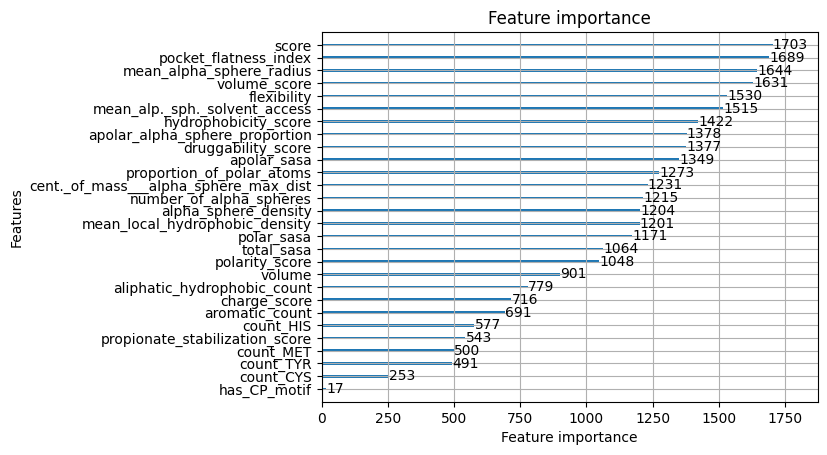

In [69]:
import matplotlib.pyplot as plt
lgb.plot_importance(final_optimized_model, max_num_features=29)
plt.show()

In [72]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import average_precision_score, classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("--- Evaluating Baseline Models --- \n")


class_weights_dict = {0: 1.0, 1: scale_pos_weight}

baselines = {
    "Random Forest": make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=150, class_weight=class_weights_dict, random_state=42, n_jobs=-1)
    ),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight=class_weights_dict, max_iter=1000, random_state=42)
    ),
    "SVM (RBF Kernel)": make_pipeline(
        StandardScaler(),
        SVC(probability=True, class_weight=class_weights_dict, random_state=42)
    )
}


pr_auc_results = {}
f1_results = {}

for model_name, pipeline in baselines.items():
    print(f"Training {model_name}...")


    pipeline.fit(X_train, y_train)


    y_probs = pipeline.predict_proba(X_test)[:, 1]


    y_pred = pipeline.predict(X_test)

    # 4. Calculate Metrics
    pr_auc = average_precision_score(y_test, y_probs)
    f1 = f1_score(y_test, y_pred)

    pr_auc_results[model_name] = pr_auc
    f1_results[model_name] = f1


    print(f"\n================ {model_name} ================")
    print(f"PR AUC Score: {pr_auc:.4f}")
    print(f"F1 Score (Default 0.5 Threshold): {f1:.4f}")
    print("-" * 40)
    print(classification_report(y_test, y_pred))
    print("================================================\n")


print("--- FINAL MODEL COMPARISON ---")
print(f"{'Model':<25} | {'PR AUC':<10} | {'F1-Score':<10}")
print("-" * 50)
for name in baselines.keys():
    print(f"{name:<25} | {pr_auc_results[name]:.4f}     | {f1_results[name]:.4f}")

print(f"{'Optimized LightGBM':<25} | {0.7820:<10} | {0.7000:<10}  <-- (custom threshold)")

--- Evaluating Baseline Models --- 

Training Random Forest...

================ Random Forest ================
PR AUC Score: 0.7715
F1 Score (Default 0.5 Threshold): 0.6073
----------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3678
           1       0.86      0.47      0.61       782

    accuracy                           0.89      4460
   macro avg       0.88      0.73      0.77      4460
weighted avg       0.89      0.89      0.88      4460


Training Logistic Regression...

================ Logistic Regression ================
PR AUC Score: 0.4778
F1 Score (Default 0.5 Threshold): 0.5390
----------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      3678
           1       0.41      0.79      0.54       782

    accuracy                           0.76      4460
   macro avg       0.68      0.77      0.69      